## 0. Download Data

In [1]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id='piebro/deutsche-bahn-data',
    repo_type='dataset',
    local_dir='data',
    allow_patterns=['monthly_processed_data/*']
)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 24 files:   0%|          | 0/24 [00:00<?, ?it/s]

'D:\\Gewissbahn - GB\\data'

# Gewissbahn-GB — Data Exploration

EDA on `piebro/deutsche-bahn-data` monthly processed parquet, nationwide Germany, 2024-07 to 2026-06.

1. File & schema overview
2. Column profiling
3. Monthly coverage
4. Delay distribution
5. Timestamps and `delay_in_min`
6. Train stop sequence
7. Station identity

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import glob

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

DATA_GLOB = 'data/monthly_processed_data/*.parquet'
files = sorted(glob.glob(DATA_GLOB))
print(f'{len(files)} monthly files found')
con = duckdb.connect()


24 monthly files found


## 1. File & Schema Overview

In [3]:
import os

file_info = pd.DataFrame({
    'file': [os.path.basename(f) for f in files],
    'size_mb': [os.path.getsize(f) / 1e6 for f in files],
})
file_info


,file,size_mb
0,data-2024-07.parquet,106.817302
1,data-2024-08.parquet,100.374556
2,data-2024-09.parquet,100.837637
3,data-2024-10.parquet,105.095082
4,data-2024-11.parquet,100.199400
5,data-2024-12.parquet,104.449176
6,data-2025-01.parquet,105.823496
7,data-2025-02.parquet,96.650628
8,data-2025-03.parquet,103.881325
9,data-2025-04.parquet,100.172066


In [4]:
# Confirm every file has the same schema (union_by_name will error/complain if columns don't line up)
schema = con.sql(f"DESCRIBE SELECT * FROM read_parquet('{DATA_GLOB}', union_by_name=true)").df()
schema


,column_name,column_type,null,key,default,extra
0,station_name,VARCHAR,YES,None,None,None
1,xml_station_name,VARCHAR,YES,None,None,None
2,eva,VARCHAR,YES,None,None,None
3,train_number,VARCHAR,YES,None,None,None
4,line_number,VARCHAR,YES,None,None,None
5,final_destination_station,VARCHAR,YES,None,None,None
6,delay_in_min,INTEGER,YES,None,None,None
7,time,TIMESTAMP_NS,YES,None,None,None
8,is_canceled,BOOLEAN,YES,None,None,None
9,train_type,VARCHAR,YES,None,None,None


## 2. Column Profiling

In [5]:
summary = con.sql(f"SUMMARIZE SELECT * FROM read_parquet('{DATA_GLOB}')").df()
summary


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,station_name,VARCHAR,Aachen Hbf,Ürzig (DB),4617,NaN,NaN,NaN,NaN,NaN,148351038,0.12
1,xml_station_name,VARCHAR,Aachen Hbf,Ürzig(DB),4422,NaN,NaN,NaN,NaN,NaN,148351038,0.00
2,eva,VARCHAR,0370014,0940370,5114,NaN,NaN,NaN,NaN,NaN,148351038,0.00
3,train_number,VARCHAR,1,99999,71903,NaN,NaN,NaN,NaN,NaN,148351038,0.00
4,line_number,VARCHAR,0,X85F,613,NaN,NaN,NaN,NaN,NaN,148351038,3.72
5,final_destination_station,VARCHAR,Aachen Hbf,Übersee,3542,NaN,NaN,NaN,NaN,NaN,148351038,0.02
6,delay_in_min,INTEGER,-1446,1475,1168,3.3965958701279866,8.426580861182543,0,1,3,148351038,0.00
7,time,TIMESTAMP_NS,2024-07-01 00:00:00,2026-06-30 23:59:00,1175314,2025-12-15 02:22:07.398182,NaN,2025-11-14 09:01:12.635835,2026-01-27 19:23:48.470557,2026-04-14 20:41:06.12129,148351038,0.00
8,is_canceled,BOOLEAN,false,true,2,NaN,NaN,NaN,NaN,NaN,148351038,0.00
9,train_type,VARCHAR,---,ÖBA,117,NaN,NaN,NaN,NaN,NaN,148351038,0.00


## 3. Monthly Coverage

In [6]:
monthly = con.sql(f"""
    SELECT
        regexp_extract(filename, 'data-(\d{{4}}-\d{{2}})', 1) AS month,
        count(*) AS n_rows,
        count(DISTINCT eva) AS n_stations,
        count(DISTINCT train_line_ride_id) AS n_train_rides,
        avg(CASE WHEN is_canceled THEN 1.0 ELSE 0.0 END) AS cancel_rate,
        min(time) AS min_time,
        max(time) AS max_time
    FROM read_parquet('{DATA_GLOB}', filename=true)
    GROUP BY month
    ORDER BY month
""").df()
monthly


<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\LENOVO 11TH\AppData\Local\Temp\ipykernel_13404\264028199.py:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\LENOVO 11TH\AppData\Local\Temp\ipykernel_13404\264028199.py:13: SyntaxWarning: invalid escape sequence '\d'
  """).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,n_rows,n_stations,n_train_rides,cancel_rate,min_time,max_time
0,2024-07,2007251,143,60506,0.052991,2024-07-01,2024-07-31 23:59:00
1,2024-08,1888035,142,61408,0.051166,2024-08-01,2024-08-31 23:59:00
2,2024-09,1904404,143,61705,0.056145,2024-09-01,2024-09-30 23:59:00
3,2024-10,1984484,142,65499,0.054254,2024-10-01,2024-10-31 23:59:00
4,2024-11,1901651,144,62612,0.050998,2024-11-01,2024-11-30 23:59:00
5,2024-12,2001242,131,54273,0.047141,2024-12-01,2024-12-31 23:59:00
6,2025-01,2016880,131,57703,0.043768,2025-01-01,2025-01-31 23:59:00
7,2025-02,1845194,131,57315,0.045498,2025-02-01,2025-02-28 23:59:00
8,2025-03,1980790,131,59892,0.047584,2025-03-01,2025-03-31 23:59:00
9,2025-04,1905985,131,61987,0.052907,2025-04-01,2025-04-30 23:59:00


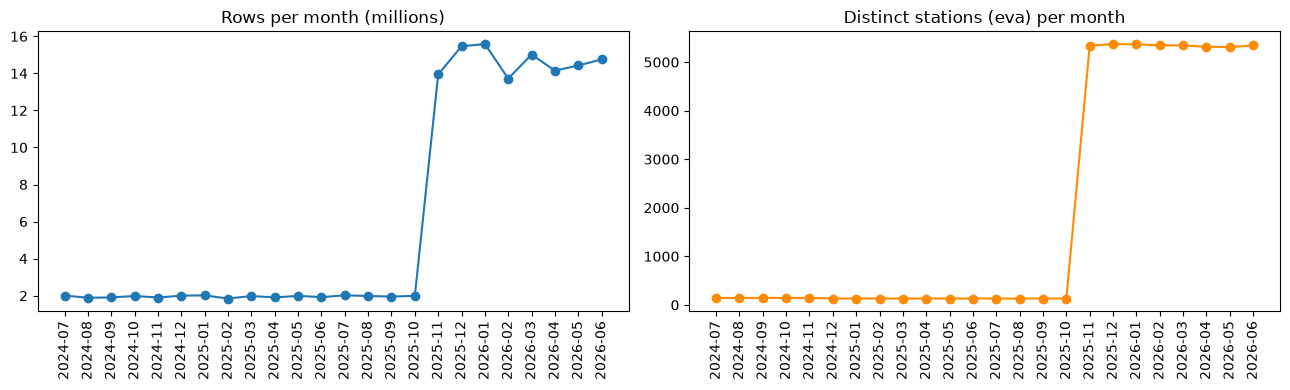

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(monthly['month'], monthly['n_rows'] / 1e6, marker='o')
axes[0].set_title('Rows per month (millions)')
axes[0].tick_params(axis='x', rotation=90)

axes[1].plot(monthly['month'], monthly['n_stations'], marker='o', color='darkorange')
axes[1].set_title('Distinct stations (eva) per month')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


## 4. Delay Distribution

In [8]:
delay_stats = con.sql(f"""
    SELECT
        count(*) AS n,
        avg(CASE WHEN is_canceled THEN 1.0 ELSE 0.0 END) AS cancel_rate,
        avg(delay_in_min) AS mean_delay,
        median(delay_in_min) AS median_delay,
        quantile_cont(delay_in_min, 0.90) AS p90,
        quantile_cont(delay_in_min, 0.95) AS p95,
        quantile_cont(delay_in_min, 0.99) AS p99,
        min(delay_in_min) AS min_delay,
        max(delay_in_min) AS max_delay,
        avg(CASE WHEN delay_in_min <= 0 THEN 1.0 ELSE 0.0 END) AS frac_on_time_or_early,
        avg(CASE WHEN delay_in_min > 5 THEN 1.0 ELSE 0.0 END) AS frac_delay_gt_5min
    FROM read_parquet('{DATA_GLOB}')
    WHERE NOT is_canceled
""").df()
delay_stats


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n,cancel_rate,mean_delay,median_delay,p90,p95,p99,min_delay,max_delay,frac_on_time_or_early,frac_delay_gt_5min
0,141826618,0.0,3.283853,1.0,8.0,14.0,34.0,-1446,1439,0.367938,0.157948


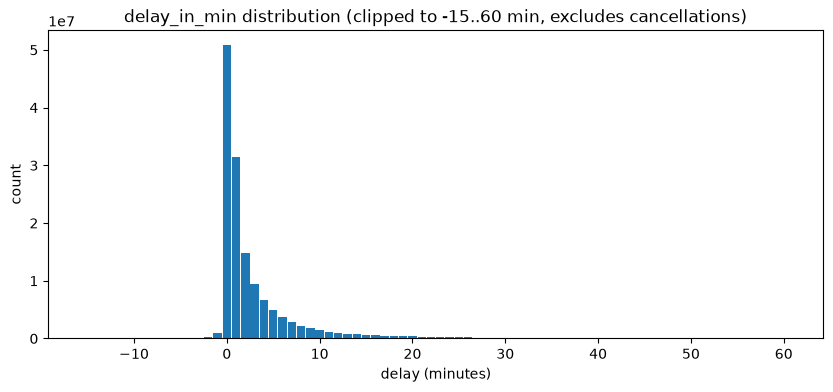

In [9]:
hist = con.sql(f"""
    SELECT delay_in_min, count(*) AS n
    FROM read_parquet('{DATA_GLOB}')
    WHERE NOT is_canceled AND delay_in_min BETWEEN -15 AND 60
    GROUP BY delay_in_min
    ORDER BY delay_in_min
""").df()

plt.figure(figsize=(10, 4))
plt.bar(hist['delay_in_min'], hist['n'], width=0.9)
plt.title('delay_in_min distribution (clipped to -15..60 min, excludes cancellations)')
plt.xlabel('delay (minutes)')
plt.ylabel('count')
plt.show()


## 5. Timestamps and `delay_in_min`

In [10]:
ts_check = con.sql(f"""
    SELECT
        avg(CASE WHEN arrival_planned_time IS NULL THEN 1.0 ELSE 0.0 END) AS null_rate_arrival_planned,
        avg(CASE WHEN arrival_change_time IS NULL THEN 1.0 ELSE 0.0 END) AS null_rate_arrival_change,
        avg(CASE WHEN departure_planned_time IS NULL THEN 1.0 ELSE 0.0 END) AS null_rate_departure_planned,
        avg(CASE WHEN departure_change_time IS NULL THEN 1.0 ELSE 0.0 END) AS null_rate_departure_change,
        -- rows where BOTH arrival timestamps exist, so we can cross-check delay_in_min
        count(*) FILTER (WHERE arrival_planned_time IS NOT NULL AND arrival_change_time IS NOT NULL) AS n_with_both_arrival_ts
    FROM read_parquet('{DATA_GLOB}')
""").df()
ts_check


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,null_rate_arrival_planned,null_rate_arrival_change,null_rate_departure_planned,null_rate_departure_change,n_with_both_arrival_ts
0,0.106878,0.106848,0.106619,0.106586,132495632


In [11]:
# Cross-check: does (arrival_change_time - arrival_planned_time) match delay_in_min?
mismatch = con.sql(f"""
    SELECT
        delay_in_min,
        date_diff('minute', arrival_planned_time, arrival_change_time) AS computed_delay,
        count(*) AS n
    FROM read_parquet('{DATA_GLOB}')
    WHERE arrival_planned_time IS NOT NULL AND arrival_change_time IS NOT NULL AND NOT is_canceled
    GROUP BY 1, 2
""").df()

mismatch['diff'] = mismatch['delay_in_min'] - mismatch['computed_delay']
total = mismatch['n'].sum()
exact_match = mismatch.loc[mismatch['diff'] == 0, 'n'].sum()
print(f'Exact match between delay_in_min and (arrival_change_time - arrival_planned_time): {exact_match/total:.2%} of rows')
mismatch.loc[mismatch['diff'] != 0].sort_values('n', ascending=False).head(10)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Exact match between delay_in_min and (arrival_change_time - arrival_planned_time): 58.16% of rows


,delay_in_min,computed_delay,n,diff
16863,1,0,11803127,1
9671,0,1,6683813,-1
9670,2,1,4254008,1
7215,1,2,2615215,-1
14305,3,2,2467035,1
0,0,-1,2202558,1
7218,4,3,1644956,1
14303,2,3,1581646,-1
2415,5,4,1183298,1
11969,3,4,1094940,-1


### What does `delay_in_min` measure?

In [12]:
arrival_diff = con.sql(f"""
    SELECT
        (delay_in_min - date_diff('minute', arrival_planned_time, arrival_change_time)) AS diff,
        count(*) AS n
    FROM read_parquet('{DATA_GLOB}')
    WHERE arrival_planned_time IS NOT NULL AND arrival_change_time IS NOT NULL AND NOT is_canceled
    GROUP BY 1
""").df()
arrival_diff['pct'] = arrival_diff['n'] / arrival_diff['n'].sum() * 100
print('abs(diff)<=1:', arrival_diff.loc[arrival_diff['diff'].abs()<=1, 'pct'].sum().round(2), '%')
arrival_diff.sort_values('n', ascending=False).head(10)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

abs(diff)<=1: 93.54 %


,diff,n,pct
343,0,73654619,58.159719
0,1,28541608,22.537241
273,-1,16262789,12.841547
208,2,2919089,2.304993
274,-2,1606748,1.268733
128,3,873439,0.689692
275,-3,580814,0.458627
475,4,463555,0.366036
278,5,279793,0.220932
131,-4,265265,0.209461


In [13]:
departure_diff = con.sql(f"""
    SELECT
        (delay_in_min - date_diff('minute', departure_planned_time, departure_change_time)) AS diff,
        count(*) AS n
    FROM read_parquet('{DATA_GLOB}')
    WHERE departure_planned_time IS NOT NULL AND departure_change_time IS NOT NULL AND NOT is_canceled
    GROUP BY 1
""").df()
departure_diff['pct'] = departure_diff['n'] / departure_diff['n'].sum() * 100
print('exact match rate:', departure_diff.loc[departure_diff['diff']==0, 'pct'].sum().round(4), '%')
departure_diff.sort_values('n', ascending=False).head(5)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

exact match rate: 100.0 %


,diff,n,pct
0,0,126737574,100.0


`delay_in_min` == `departure_change_time - departure_planned_time`, exact match on 100% of rows. It is departure delay, not arrival delay. Arrival delay must be computed separately as `arrival_change_time - arrival_planned_time`.

## 6. Train Stop Sequence

In [14]:
sample_ride = con.sql(f"""
    SELECT train_line_ride_id, count(*) AS n_stops
    FROM read_parquet('data/monthly_processed_data/data-2024-07.parquet')
    GROUP BY train_line_ride_id
    HAVING count(*) >= 5
    LIMIT 1
""").df()
ride_id = sample_ride.loc[0, 'train_line_ride_id']
print('Sample ride_id:', ride_id)

con.sql(f"""
    SELECT train_line_ride_id, train_line_station_num, station_name, eva,
           arrival_planned_time, departure_planned_time, delay_in_min
    FROM read_parquet('data/monthly_processed_data/data-2024-07.parquet')
    WHERE train_line_ride_id = '{ride_id}'
    ORDER BY train_line_station_num
""").df()


Sample ride_id: 7592709310719899774


,train_line_ride_id,train_line_station_num,station_name,eva,arrival_planned_time,departure_planned_time,delay_in_min
0,7592709310719899774,1,Nürnberg Hbf,08000284,NaT,2024-07-03 10:10:00,0
1,7592709310719899774,1,Nürnberg Hbf,08000284,NaT,2024-07-01 10:10:00,2
2,7592709310719899774,1,Nürnberg Hbf,08000284,NaT,2024-07-20 10:10:00,10
3,7592709310719899774,1,Nürnberg Hbf,08000284,NaT,2024-07-21 10:10:00,1
4,7592709310719899774,1,Nürnberg Hbf,08000284,NaT,2024-07-31 10:10:00,2
...,...,...,...,...,...,...,...
88,7592709310719899774,6,Bamberg,08000025,2024-07-01 10:54:00,2024-07-01 10:55:00,0
89,7592709310719899774,6,Bamberg,08000025,2024-07-23 10:54:00,2024-07-23 10:55:00,2
90,7592709310719899774,6,Bamberg,08000025,2024-07-08 10:54:00,2024-07-08 10:55:00,1
91,7592709310719899774,6,Bamberg,08000025,2024-07-09 10:54:00,2024-07-09 10:55:00,10


`train_line_ride_id` repeats across calendar dates (it identifies a scheduled line pattern, not a single journey). Per-journey stop sequence requires grouping by `(train_line_ride_id, service date)`.

## 7. Station Identity

In [15]:
sample = con.sql(f"""
    SELECT DISTINCT station_name, eva
    FROM read_parquet('data/monthly_processed_data/data-2024-07.parquet')
    WHERE station_name ILIKE '%ö%' OR station_name ILIKE '%ü%' OR station_name ILIKE '%ä%' OR station_name ILIKE '%ß%'
    LIMIT 10
""").df()
sample


,station_name,eva
0,Mönchengladbach Hbf,08000253
1,Berlin Friedrichstraße,08089066
2,Würzburg Hbf,08000260
3,Osnabrück Hbf,08000294
4,Köln Hbf,08000207
5,Frankfurt (Main) Süd,08002041
6,Berlin Südkreuz,08089073
7,Düsseldorf Hbf,08000085
8,Lüneburg,08000238
9,Göttingen,08000128


In [16]:
id_check = con.sql(f"""
    SELECT
        count(DISTINCT eva) AS n_distinct_eva,
        count(DISTINCT station_name) AS n_distinct_station_name,
        count(DISTINCT xml_station_name) AS n_distinct_xml_station_name
    FROM read_parquet('data/monthly_processed_data/data-2024-07.parquet')
""").df()
id_check


,n_distinct_eva,n_distinct_station_name,n_distinct_xml_station_name
0,143,108,143


## 8. Live Timetables API

In [17]:
import os
import datetime
import requests
from dotenv import load_dotenv

load_dotenv()

TIMETABLES_BASE = 'https://apis.deutschebahn.com/db-api-marketplace/apis/timetables/v1'
headers = {
    'DB-Client-Id': os.environ['Client_ID'],
    'DB-Api-Key': os.environ['Client_API'],
    'Accept': 'application/xml',
}


In [18]:
eva = '8000207'  # Koeln Hbf
now = datetime.datetime.now()
url = f"{TIMETABLES_BASE}/plan/{eva}/{now:%y%m%d}/{now:%H}"

resp = requests.get(url, headers=headers, timeout=15)
print(resp.status_code)


200


In [19]:
import xml.etree.ElementTree as ET

root = ET.fromstring(resp.text)
rows = []
for s in root.findall('s'):
    tl = s.find('tl')
    ar = s.find('ar')
    dp = s.find('dp')
    rows.append({
        'train': f"{tl.get('c')} {tl.get('n')}" if tl is not None else None,
        'arrival_planned': ar.get('pt') if ar is not None else None,
        'arrival_platform': ar.get('pp') if ar is not None else None,
        'departure_planned': dp.get('pt') if dp is not None else None,
        'departure_platform': dp.get('pp') if dp is not None else None,
    })
pd.DataFrame(rows).head(15)


,train,arrival_planned,arrival_platform,departure_planned,departure_platform
0,ICE 127,2607241711,6 A-C,2607241718,6 A-C
1,RB 10631,2607241735,4 D-G,2607241738,4 D-G
2,RB 10276,2607241726,7 D-G,2607241729,7 D-G
3,S 32011,2607241739,11 B-C,2607241740,11 B-C
4,S 33224,2607241709,10 A-B,2607241710,10 A-B
5,RB 10437,2607241658,6 D-G,2607241702,6 D-G
6,RE 10037,2607241718,8 D-G,2607241721,8 D-G
7,S 33116,2607241722,10 A-B,2607241727,10 A-B
8,S 33225,2607241709,11 B-C,2607241710,11 B-C
9,RE 10830,2607241753,8 D-G,2607241759,8 D-G
